# S2S Model Sandbox
-------------------


In [103]:
# data & IO
import pandas as pd
import numpy as np
from pathlib import Path
import shutil

# torch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchinfo

# sci-kit learn
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import train_test_split

# plot
import seaborn as sns
import matplotlib.pyplot as plt
# from utility import read_and_write


# Data Generation

---


In [104]:
def gaussian(x, mu, sigma):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2)
    # return (1.0 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def spectrum_generation(number_of_grid_points, peak_setting, variation_setting, normalization=True, random_seed=999):
    # create perfect spectrum
    # initiation
    grid = np.linspace(0, 1, number_of_grid_points) 
    total_intensity = np.zeros(number_of_grid_points)
    df = pd.DataFrame({'BE': grid, 'I': np.zeros(number_of_grid_points)})
    for setting in peak_setting:
        if setting['type'] == 'gaussian':
            center = setting['p1']
            sigma = setting['p2']
            scaling = setting['scaling']
            total_intensity += scaling*gaussian(grid, center, sigma)
        elif setting['type'] == 'linear':
            slope = setting['p1']
            shift = setting['p2']
            total_intensity += grid*slope+shift
        else:
            Exception('Unknown type for spectrum generation')
    df['I'] = total_intensity

    # create variated spectrum
    # initiation
    total_intensity = np.zeros(number_of_grid_points)
    x_shift = 0
    x_stretch = 1
    for setting in variation_setting:
        if setting['type'] == 'shift':
            x_shift = setting['p1']
        if setting['type'] == 'stretch':
            x_stretch = setting['p1']
            x_stretch_center = setting['p2']
        if setting['type'] == 'noise':
            total_intensity += np.random.default_rng(seed=random_seed).uniform(size=number_of_grid_points, low=-setting['p1'], high=setting['p1'])

    # create perfect spectrum
    df_variated = pd.DataFrame({'BE': grid, 'I': np.zeros(number_of_grid_points)})
    for setting in peak_setting:
        if setting['type'] == 'gaussian':
            center = setting['p1']
            sigma = setting['p2']
            scaling = setting['scaling']
            total_intensity += scaling*gaussian((grid-x_stretch_center)/x_stretch+x_stretch_center-x_shift, center, sigma)
        elif setting['type'] == 'linear':
            slope = setting['p1']
            shift = setting['p2']
            total_intensity += ((grid-x_stretch_center)/x_stretch+x_stretch_center-x_shift)*slope+shift
        else:
            Exception('Unknown type for spectrum generation')
    df_variated['I'] = total_intensity
    if normalization:
        df['I'] = (df['I'] - df['I'].min())/(df['I'].max() - df['I'].min())
        df_variated['I'] = (df_variated['I'] - df_variated['I'].min())/(df_variated['I'].max() - df_variated['I'].min())
    df['I_variated'] = df_variated['I']
    # assign random group
    df['group'] = np.random.default_rng(seed=random_seed).integers(0,9,len(df))
    return df

# generate spectra
number_of_spectra = 100
peak_setting = [
    {'type': 'gaussian', 'p1': 0.3, 'p2': 0.05, 'scaling':1}, 
    {'type': 'gaussian', 'p1': 0.5, 'p2': 0.09, 'scaling':0.5},
    {'type': 'linear', 'p1': 0.1, 'p2': 0},
]
varition_setting = [
    {'type': 'shift', 'p1': 0.1}, # shift amount
    {'type': 'stretch', 'p1': 1.1, 'p2': 0.5}, # strech , strech center
    {'type': 'noise', 'p1':0.015} # noise strength
]

number_of_grid_points = 100
spectra = []
spectra_variated = []
seed = np.random.default_rng(seed=99).integers(size=number_of_spectra, low=1, high=1000000)
for i in range(number_of_spectra):
    df = spectrum_generation(number_of_grid_points, peak_setting, varition_setting, True, random_seed=seed[i])
    spectra.append(df)

# Spectrum Plot

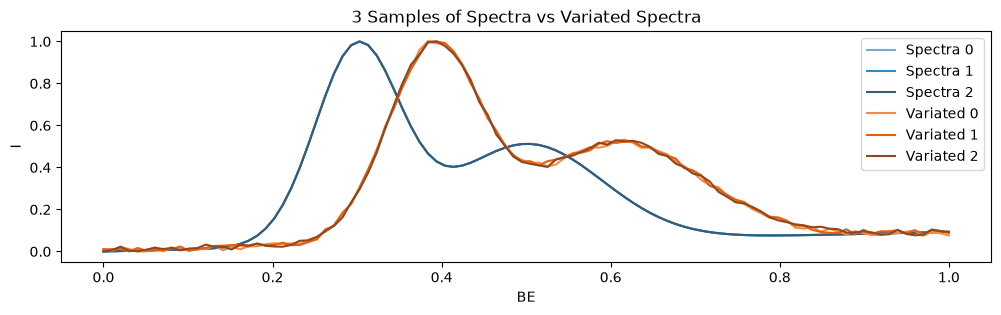

In [105]:
colors_spectra = sns.color_palette("Blues_d", 3)
colors_variated = sns.color_palette("Oranges_d", 3)

plt.figure(figsize=(12, 3))

samplings = [0, 1, 2]

for i in samplings:
    sns.lineplot(data=spectra[i], x='BE', y='I', color=colors_spectra[i], label=f'Spectra {i}')
for i in samplings:
    sns.lineplot(data=spectra[i], x='BE', y='I_variated', color=colors_variated[i], label=f'Variated {i}')

plt.title("3 Samples of Spectra vs Variated Spectra")
plt.legend()
plt.show()

# Model

---


## Model Definition

In [106]:
models = dict()


### Basic CNN

In [107]:
class model_CNN_basic(nn.Module):
    def __init__(self, model_parameters):
        super().__init__()
        self.model_parameters = model_parameters
        # layer 0
        MP = self.model_parameters[0]
        self.cnn_layer0 = nn.Conv1d(MP['in_channels'], MP['out_channels'], MP['kernel'], MP['stride'], MP['padding'], MP['dilation'], 1, True, MP['padding_mode'])
        self.batch_norm0 = nn.BatchNorm1d(MP['out_channels'])
        # layer 1
        MP = self.model_parameters[1]
        self.cnn_layer1 = nn.Conv1d(MP['in_channels'], MP['out_channels'], MP['kernel'], MP['stride'], MP['padding'], MP['dilation'], 1, True, MP['padding_mode'])
        self.batch_norm1 = nn.BatchNorm1d(MP['out_channels'])
        # layer 2
        MP = self.model_parameters[2]
        self.cnn_layer2 = nn.Conv1d(MP['in_channels'], MP['out_channels'], MP['kernel'], MP['stride'], MP['padding'], MP['dilation'], 1, True, MP['padding_mode'])          
        self.batch_norm2 = nn.BatchNorm1d(MP['out_channels'])

    def forward(self, x):
        # layer 0
        x = self.cnn_layer0(x)
        x = self.batch_norm0(x)
        x = F.relu(x)
        # layer 1
        x = self.cnn_layer1(x)
        x = self.batch_norm1(x)
        x = F.relu(x)
        # layer 2
        x = self.cnn_layer2(x)
        x = self.batch_norm2(x)
        # x = F.relu(x)
        return x

model_parameters =[
    {'in_channels': 1, 'out_channels': 64, 'kernel': 3, 'stride':1, 'padding': 1, 'padding_mode': 'replicate', 'dilation': 1}, # 1st CNN layer
    {'in_channels': 64, 'out_channels':32, 'kernel': 3, 'stride':1, 'padding': 1, 'padding_mode': 'replicate', 'dilation': 1}, # 2nd CNN layer
    {'in_channels': 32, 'out_channels': 1, 'kernel': 3, 'stride':1, 'padding': 1, 'padding_mode': 'replicate', 'dilation': 1}, # 3rd CNN layer
]

model = dict() # make sure model is not contaminated by other model declarations
model['name'] = 'model_CNN_basic'
model['parameters'] = model_parameters
model['net'] = model_CNN_basic(model_parameters)
models[model['name']] =model
torchinfo.summary(model['net'], input_size=(100, 1, 100))

Layer (type:depth-idx)                   Output Shape              Param #
model_CNN_basic                          [100, 1, 100]             --
├─Conv1d: 1-1                            [100, 64, 100]            256
├─BatchNorm1d: 1-2                       [100, 64, 100]            128
├─Conv1d: 1-3                            [100, 32, 100]            6,176
├─BatchNorm1d: 1-4                       [100, 32, 100]            64
├─Conv1d: 1-5                            [100, 1, 100]             97
├─BatchNorm1d: 1-6                       [100, 1, 100]             2
Total params: 6,723
Trainable params: 6,723
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 65.31
Input size (MB): 0.04
Forward/backward pass size (MB): 15.52
Params size (MB): 0.03
Estimated Total Size (MB): 15.59

In [108]:
class model_CNN_basic_4L(nn.Module):
    def __init__(self, model_parameters):
        super().__init__()
        self.model_parameters = model_parameters
        # layer 0
        MP = self.model_parameters[0]
        self.cnn_layer0 = nn.Conv1d(MP['in_channels'], MP['out_channels'], MP['kernel'], MP['stride'], MP['padding'], MP['dilation'], 1, True, MP['padding_mode'])
        self.batch_norm0 = nn.BatchNorm1d(MP['out_channels'])
        # layer 1
        MP = self.model_parameters[1]
        self.cnn_layer1 = nn.Conv1d(MP['in_channels'], MP['out_channels'], MP['kernel'], MP['stride'], MP['padding'], MP['dilation'], 1, True, MP['padding_mode'])
        self.batch_norm1 = nn.BatchNorm1d(MP['out_channels'])
        # layer 2
        MP = self.model_parameters[2]
        self.cnn_layer2 = nn.Conv1d(MP['in_channels'], MP['out_channels'], MP['kernel'], MP['stride'], MP['padding'], MP['dilation'], 1, True, MP['padding_mode'])          
        self.batch_norm2 = nn.BatchNorm1d(MP['out_channels'])
        # layer 3
        MP = self.model_parameters[3]
        self.cnn_layer3 = nn.Conv1d(MP['in_channels'], MP['out_channels'], MP['kernel'], MP['stride'], MP['padding'], MP['dilation'], 1, True, MP['padding_mode'])          
        self.batch_norm3 = nn.BatchNorm1d(MP['out_channels'])

    def forward(self, x):
        # layer 0
        x = self.cnn_layer0(x)
        x = self.batch_norm0(x)
        x = F.relu(x)
        # layer 1
        x = self.cnn_layer1(x)
        x = self.batch_norm1(x)
        x = F.relu(x)
        # layer 2
        x = self.cnn_layer2(x)
        x = self.batch_norm2(x)
        x = F.relu(x)
        # layer 3
        x = self.cnn_layer3(x)
        x = self.batch_norm3(x)
        # x = F.relu(x)
        return x

model_parameters =[
    {'in_channels': 1, 'out_channels': 16, 'kernel': 11, 'stride':1, 'padding': 1, 'padding_mode': 'replicate', 'dilation': 1}, # 1st CNN layer
    {'in_channels': 16, 'out_channels':8, 'kernel': 7, 'stride':1, 'padding': 1, 'padding_mode': 'replicate', 'dilation': 1}, # 2nd CNN layer
    {'in_channels': 8, 'out_channels': 4, 'kernel': 3, 'stride':1, 'padding': 1, 'padding_mode': 'replicate', 'dilation': 1}, # 3rd CNN layer
    {'in_channels':  4, 'out_channels': 1, 'kernel': 3, 'stride':1, 'padding': 1, 'padding_mode': 'replicate', 'dilation': 1}, # 4th CNN layer
]

model = dict() # make sure model is not contaminated by other model declarations
model['name'] = 'model_CNN_basic_4L'
model['parameters'] = model_parameters
model['net'] = model_CNN_basic(model_parameters)
models[model['name']] =model
torchinfo.summary(model['net'], input_size=(number_of_spectra, 1, number_of_grid_points))

Layer (type:depth-idx)                   Output Shape              Param #
model_CNN_basic                          [100, 4, 88]              --
├─Conv1d: 1-1                            [100, 16, 92]             192
├─BatchNorm1d: 1-2                       [100, 16, 92]             32
├─Conv1d: 1-3                            [100, 8, 88]              904
├─BatchNorm1d: 1-4                       [100, 8, 88]              16
├─Conv1d: 1-5                            [100, 4, 88]              100
├─BatchNorm1d: 1-6                       [100, 4, 88]              8
Total params: 1,252
Trainable params: 1,252
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 10.61
Input size (MB): 0.04
Forward/backward pass size (MB): 4.04
Params size (MB): 0.01
Estimated Total Size (MB): 4.09

In [109]:
# # get all class name in current scope (useful for listing all defined models alter)
# import inspect

# class UserProfile: pass
# class OrderHistory: pass

# for name, obj in globals().items():
#     if inspect.isclass(obj) and obj.__module__ == __name__:
#         print(name)

### ResNet

In [110]:
model = dict() # make sure model is not contaminated by other model declarations
model['name'] = 'model_CNN_basic_4L'
# model['parameters'] = model_parameters
# model['net'] = model_ResNet3L(model_parameters)
models[model['name']] =model
# torchinfo.summary(model['net'], input_size=(100, 1, 100))

### ResNet + Global BE

### ResNet + Sliding Window

### ResNet + STN

### ResNet + Bayesian Optimization

ResNet + All

## Model Training

### parameter setup

In [120]:
# user defined parameters
print('Available models:', models.keys())
model_chosen = 'model_CNN_basic'
epochs = 25
batch_size = 8
learning_rate = 500e-3

# setting up other parameters
model = models[model_chosen]
net = model['net']
model_parameters = model['parameters']


# training utilities
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(net.parameters(), lr=learning_rate)
# optimizer = torch.optim.SGD(net.parameters(), lr=learning_rate, momentum=0.9)
scheduler_on = True
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.9)

Available models: dict_keys(['model_CNN_basic', 'model_CNN_basic_4L'])


### Data refactoring

In [121]:
# 假設 A 是你的資料 List，裡面有許多個 DataFrame
# A = [df1, df2, df3, ...] 

# ==========================================
# 步驟一：直接對 List A 進行 Train/Test 切分
# ==========================================
# test_size=0.2 代表 80% 訓練、20% 測試
train_spectra, test_spectra = train_test_split(spectra, test_size=0.5, random_state=42)


# ==========================================
# 步驟二：提取資料並用 np.stack 堆疊成二維矩陣
# ==========================================
# 利用列表推導式 (List Comprehension) 遍歷 DataFrame
# 並強制指定型態為 float32 以符合 PyTorch 預設需求

# 訓練集
X_train_num = torch.tensor(np.stack([df['I_variated'].to_numpy() for df in train_spectra]).astype(np.float32))
y_train_num = torch.tensor(np.stack([df['I'].to_numpy() for df in train_spectra]).astype(np.float32))
X_train_num.unsqueeze_(1)
y_train_num.unsqueeze_(1)

# 測試集
X_test_num = torch.tensor(np.stack([df['I_variated'].to_numpy() for df in test_spectra]).astype(np.float32))
y_test_num = torch.tensor(np.stack([df['I'].to_numpy() for df in test_spectra]).astype(np.float32))
X_test_num.unsqueeze_(1)
y_test_num.unsqueeze_(1)

# ==========================================
# 步驟三：轉換為 PyTorch Tensor 並打包成 Dataset
# ==========================================
train_dataset = torch.utils.data.TensorDataset(X_train_num, y_train_num)

test_dataset = torch.utils.data.TensorDataset(X_test_num, y_test_num)


# ==========================================
# 步驟四：建立 DataLoader
# ==========================================
# 訓練集建議 shuffle=True 來打亂順序；測試集 shuffle=False 依序評估即可
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# ==========================================
# 驗證維度
# ==========================================
print(f"訓練集總樣本數: {len(train_dataset)}")
print(f"測試集總樣本數: {len(test_dataset)}")

# 取出一個 batch 檢查維度
first_X_batch, first_y_batch = next(iter(train_loader))
print(f"一個 Batch 的輸入形狀: {first_X_batch.shape}") # 預期為 [32, 光譜長度]
print(f"一個 Batch 的輸出形狀: {first_y_batch.shape}") # 預期為 [32, 光譜長度]

訓練集總樣本數: 50
測試集總樣本數: 50
一個 Batch 的輸入形狀: torch.Size([8, 1, 100])
一個 Batch 的輸出形狀: torch.Size([8, 1, 100])


In [122]:
# #TODO: split with group (die)
# gss = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
# # 3. 取得 Train 和 Test 的 index
# train_idx, test_idx = next(gss.split(df, groups=df['group']))
# # 4. 切分 DataFrame
# train_df = df.iloc[train_idx]
# test_df = df.iloc[test_idx]
# print(f"Train Groups: {train_df['group'].unique()}")
# print(f"Test Groups: {test_df['group'].unique()}")
# # 5. 轉換為 PyTorch TensorDataset (如同先前教的方法)
# # 使用 np.stack 將 list of arrays 轉成 2D numpy array 再轉 tensor
# train_dataset = torch.utils.data.TensorDataset(
#     torch.tensor(np.stack(train_df['input_spec'].values), dtype=torch.float32),
#     torch.tensor(np.stack(train_df['output_spec'].values), dtype=torch.float32)
# )

In [123]:
# # old data splitting
# # stack each spectrum together
# lst = list()
# region_length = number_of_grid_points
# for spectrum in spectra:
#     lst.append(spectrum[['I_variated', 'I']])
# df_tmp = pd.concat(lst)


# train_set, test_set = torch.utils.data.random_split(df_tmp, lengths=[0.5, 0.5])
# train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)
# test_loader = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=True)

<Axes: ylabel='None'>

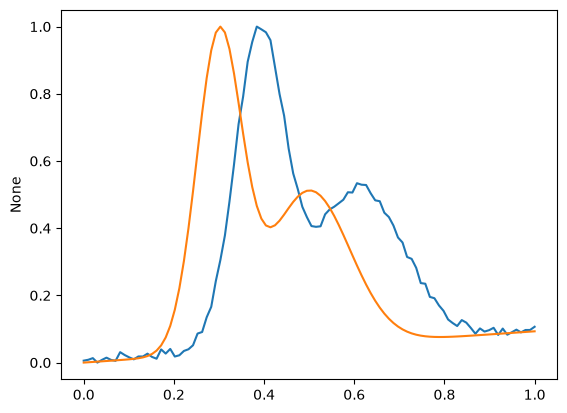

In [124]:
first_X_batch, first_y_batch = next(iter(train_loader))

sns.lineplot(x=np.linspace(0, 1, number_of_grid_points), y=first_X_batch[0,0])
sns.lineplot(x=np.linspace(0, 1, number_of_grid_points), y=first_y_batch[0,0])

In [125]:
# # Convert the dataloader into a Python iterator
# data_iter = iter(train_loader)

# # Extract the very first batch
# inputs, targets = next(data_iter)

# print("Single batch inputs shape:", inputs.shape)

### Training

In [126]:
history = {'loss_train': [], 'loss_validation': []}
# TODO: add validation set; currently validation = test
validation_loader = test_loader

for epoch in range(epochs):
    # training
    net.train()
    loss_train = 0
    for x_train_batch, y_train_batch in train_loader:    
        optimizer.zero_grad()
        y_train_pred_batch = net(x_train_batch)
        loss = criterion(y_train_pred_batch, y_train_batch)
        loss_train += loss.item()
        loss.backward()
        optimizer.step()

    history['loss_train'].append(loss_train)

    # validation
    net.eval()
    with torch.no_grad():
        loss_validation = 0
        for x_validation_batch, y_validation_batch in validation_loader:    
            y_validation_pred_batch = net(x_validation_batch)
            loss = criterion(y_validation_pred_batch, y_validation_batch)
            loss_validation += loss.item()
        history['loss_validation'].append(loss_validation)
    
    if scheduler_on:
        scheduler.step(loss_validation)
    
    print(f'Epoch {epoch}/{epochs}: loss_train: {np.log10(loss_train):.4f}; loss_validation: {np.log10(loss_validation):.4f}')


Epoch 0/25: loss_train: 0.0794; loss_validation: -0.2911
Epoch 1/25: loss_train: -0.1923; loss_validation: 0.2175
Epoch 2/25: loss_train: -0.3649; loss_validation: 0.4966
Epoch 3/25: loss_train: -0.6671; loss_validation: -0.1352
Epoch 4/25: loss_train: -1.0956; loss_validation: -0.6074
Epoch 5/25: loss_train: -1.3428; loss_validation: -0.7178
Epoch 6/25: loss_train: -1.5462; loss_validation: -0.9878
Epoch 7/25: loss_train: -1.6915; loss_validation: -1.2084
Epoch 8/25: loss_train: -1.8062; loss_validation: -1.6233
Epoch 9/25: loss_train: -1.8508; loss_validation: -1.5864
Epoch 10/25: loss_train: -1.9189; loss_validation: -1.6860
Epoch 11/25: loss_train: -1.9576; loss_validation: -1.9182
Epoch 12/25: loss_train: -1.9833; loss_validation: -1.9555
Epoch 13/25: loss_train: -2.0053; loss_validation: -1.9501
Epoch 14/25: loss_train: -2.0172; loss_validation: -1.9900
Epoch 15/25: loss_train: -1.9934; loss_validation: -1.8759
Epoch 16/25: loss_train: -2.0146; loss_validation: -1.9809
Epoch 17/2

# Performance

---


<Axes: >

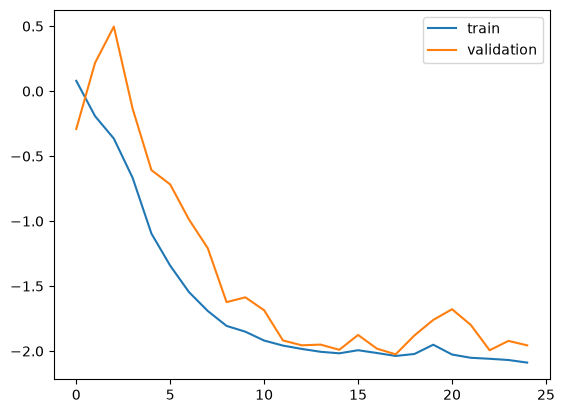

In [127]:
sns.lineplot(np.log10(history['loss_train']), label='train')
sns.lineplot(np.log10(history['loss_validation']), label='validation')

## Cost

## Spectrum Comparison

<Axes: ylabel='None'>

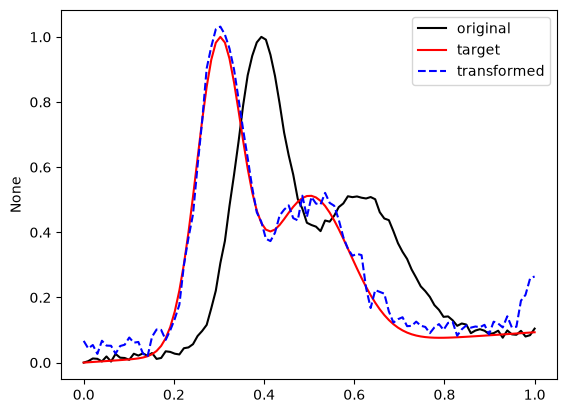

In [128]:
first_X_batch, first_y_batch = next(iter(test_loader))
net.eval()
sample = 0
with torch.no_grad():
    y_test_pred_batch = net(first_X_batch)

sns.lineplot(x=np.linspace(0, 1, number_of_grid_points), y=first_X_batch[sample,0], label='original', color='black')
sns.lineplot(x=np.linspace(0, 1, number_of_grid_points), y=first_y_batch[sample,0], label='target', color='red')
sns.lineplot(x=np.linspace(0, 1, number_of_grid_points), y=y_test_pred_batch[sample,0], label='transformed', color='blue', linestyle='--')
